<h1 align="center">CAMM Hackathon - Session 1</h1>
<p align="left"><em>26 September 2025</em></p>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KBForgeX/camm_hackathon/blob/k4my4r/docs/regressors/CAMM_Hackathon_1.ipynb)




**Data provenance** : The dataset aggregates measurements from a Dy–Er–Gd–Ho oxide wafer study in the CAMM by the Rack and Page groups


<h3>Goal: Feature → Target Prediction</h3>


This notebook hands you a **clean, standardized dataset** and a minimal prep pipeline so you can build your own predictive models. Your goal is to use the provided **features** (materials/structure descriptors) to **predict a target property** (default: *Thermal Conductivity*). The notebook **stops at data preparation**—you will implement and compare models (e.g., linear models, trees, neural nets) using the prepared data.

**What you’ll find here**
- A tidy table with `x`, `y` wafer coordinates and a set of engineered features (numeric, aligned to the same grid, with units harmonized).
- A simple example showing how to **select a target and features**, coerce to numeric, handle missing values (median imputation), and standardize inputs—ready for modeling.
- You can swap the target and feature lists to explore different prediction tasks.

**What you will do**
- Choose a **target** (e.g., `Thermal Conductivity`) and a subset of **features** you think are predictive.
- Train any models you like (sklearn, PyTorch, etc.) on the **prepared arrays**.
- Report basic metrics (RMSE, MAE, $R^2$) and, if useful, visualize predictions on the wafer grid using `x`, `y`.


#Data Preparation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
!gdown --fuzzy https://drive.google.com/file/d/1BSZ3YyTw6dqELnL9qpfV8V5wVrbA-BPz/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1BSZ3YyTw6dqELnL9qpfV8V5wVrbA-BPz
To: /content/ReZrO_data.csv
100% 513k/513k [00:00<00:00, 130MB/s]


In [ ]:
path = "/content/ReZrO_data.csv"   # update if path differs
df = pd.read_csv(path)

Let's see what all properties we have in the dataset

In [ ]:
print("Dataframe shape:", df.shape)
display(df.head())


Dataframe shape: (2601, 17)


,x,y,Thermal Conductivity,Lattice Parameter(WPF),delta_d(SPF-WPF),d-spacing(WPF),Fluorite Size Disorder,Entropy,strain(LMFIT-dspacing),a111(LMFIT),a200(LMFIT),mismatch(LMFIT-lattice parameter),d111(LMFIT),d200(LMFIT),corr_length,fwhm111(LMFIT),delta_d/d
0,-2.5,-2.5,0.668247,5.245110,0.020399,2.622555,0.103832,3.924187,0.127131,5.245331,5.286782,-0.007902,3.028393,2.643391,2.94866,0.097076,0.007778
1,-2.5,-2.4,0.651635,5.245110,0.020399,2.622555,0.103727,3.927794,0.127131,5.245331,5.286782,-0.007902,3.028393,2.643391,2.94866,0.097076,0.007778
2,-2.5,-2.3,0.661063,5.244901,0.019877,2.622450,0.103588,3.939862,0.127240,5.245438,5.286226,-0.007776,3.028455,2.643113,2.94866,0.096367,0.007580
3,-2.5,-2.2,0.594712,5.244901,0.019877,2.622450,0.103447,3.951859,0.127240,5.245438,5.286226,-0.007776,3.028455,2.643113,2.94866,0.096367,0.007580
4,-2.5,-2.1,0.620809,5.244680,0.019664,2.622340,0.103338,3.955091,0.127249,5.245217,5.285954,-0.007766,3.028328,2.642977,2.94866,0.095942,0.007499


Let's plot them and see how they look

### Feature Definitions

1. **Lattice Parameter (WPF)**  
   Calculated by fitting the **whole XRD spectrum** using **TOPAS**.

2. **d-spacing (WPF)**  
   Average d-spacing calculated from fitting all peaks.

3. **Δd (SPF–WPF)**  
   Difference between *d-spacing (200 peak)* (2nd XRD peak) and *d-spacing (WPF)*:  
   $$ \Delta d = d_{WPF} - d_{\text{SPF}} $$

4. **delta_d/d**  
   Strain calculated from (2) and (3):  
   $$ \frac{\Delta d}{d} = \frac{d_{WPF} - d_{\text{SPF}}}{d_{\text{WPF}}} $$

5. **a111 (LMFit)**  
   Lattice parameter from fitting the **111 peak** (1st XRD peak) using the **LMFit** package.

6. **a200 (LMFit)**  
   Lattice parameter from fitting the **200 peak** (2nd XRD peak) using **LMFit**.

7. **Mismatch (LMFit – lattice parameter)**  
   $$ \text{Mismatch} = \frac{a_{111} - a_{200}}{a_{111}} $$

8. **d111 (LMFit)**  
   d-spacing of the 111 peak from LMFit.

9. **d200 (LMFit)**  
   d-spacing of the 200 peak from LMFit.

10. **Correlation Length**  
    Calculated from AFM images.

11. **FWHM111 (LMFit)**  
    Full Width at Half Maximum of the **111 peak**.

12. **Strain (LMFit – d-spacing)**  
    Strain calculated using LMFit d-spacing values:  
    $$ \frac{\Delta d}{d}{LMFIT} = \frac{d_{111} - d_{200}}{d_{111}} $$


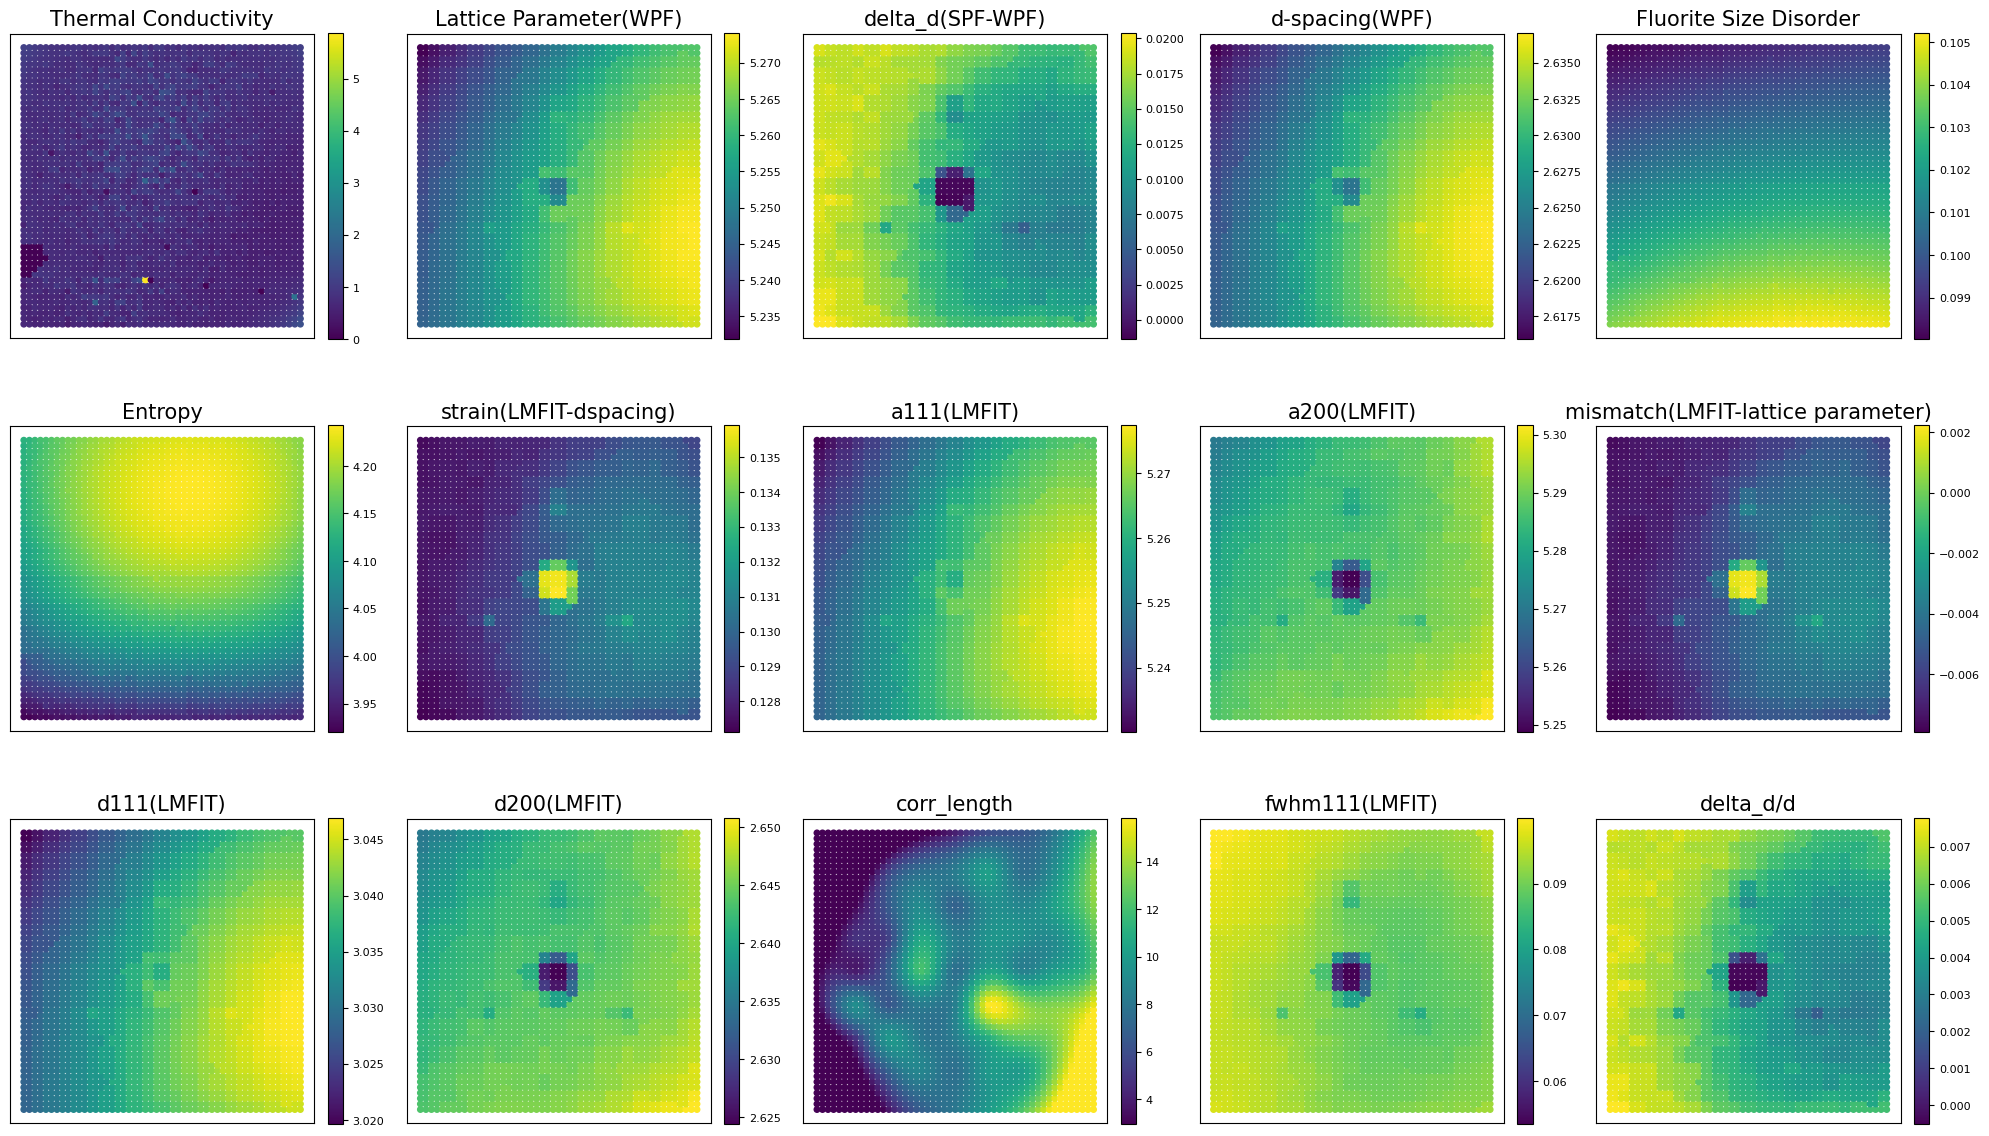

In [ ]:
x = df["x"].to_numpy()
y = df["y"].to_numpy()

feature_cols = [c for c in df.columns if c not in ["x", "y"]]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    z = pd.to_numeric(df[col], errors="coerce").to_numpy()
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

    sc = ax.scatter(x[mask], y[mask], c=z[mask], s=16, cmap="viridis")
    ax.set_title(col, fontsize=15)
    ax.set_aspect("equal", "box")
    ax.set_xticks([]); ax.set_yticks([])

    # colorbar for each subplot
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

# Hide any unused subplots
for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# How to use this to train in networks?

In [ ]:
features = [
    'a111(LMFIT)', 'mismatch(LMFIT-lattice parameter)',
    'Fluorite Size Disorder', 'Entropy',
    'corr_length',
]
target = 'Thermal Conductivity'

missing = [c for c in features + [target] if c not in df.columns]
if missing:
    raise KeyError(f"These columns are missing in df: {missing}")

In [ ]:
for c in features + [target]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 3) drop rows with missing target
df_clean = df.dropna(subset=[target]).copy()

# 4) build matrices
X_raw = df_clean[features].to_numpy(dtype=np.float32) # Input features
y_raw = df_clean[target].to_numpy(dtype=np.float32)[:, None] #Target feature that needs to be predicted
XY    = df_clean[["x","y"]].to_numpy(dtype=np.float32) if set(["x","y"]).issubset(df_clean.columns) else None # can be used to plot predictions back on the grid


In [ ]:
X_train_raw, X_val_raw, y_train, y_val, XY_train, XY_val = train_test_split(
    X_raw, y_raw, XY, test_size=0.2, random_state=42
)
# Use this to split into training and testing dataset

We split the dataset into training and test sets because we want to test our model on unseen data

## Build your network now

Make use of Chatgpt and build your own network to predict one of the features you select

🚀 Starting Feature-Specific Thermal Conductivity Prediction
📋 Selected Features: ['a111(LMFIT)', 'mismatch(LMFIT-lattice parameter)', 'Fluorite Size Disorder', 'Entropy', 'corr_length']
📊 Test Set Size: 20% (spatially separated)
🎯 Output Directory: /content/outputs
--------------------------------------------------------------------------------


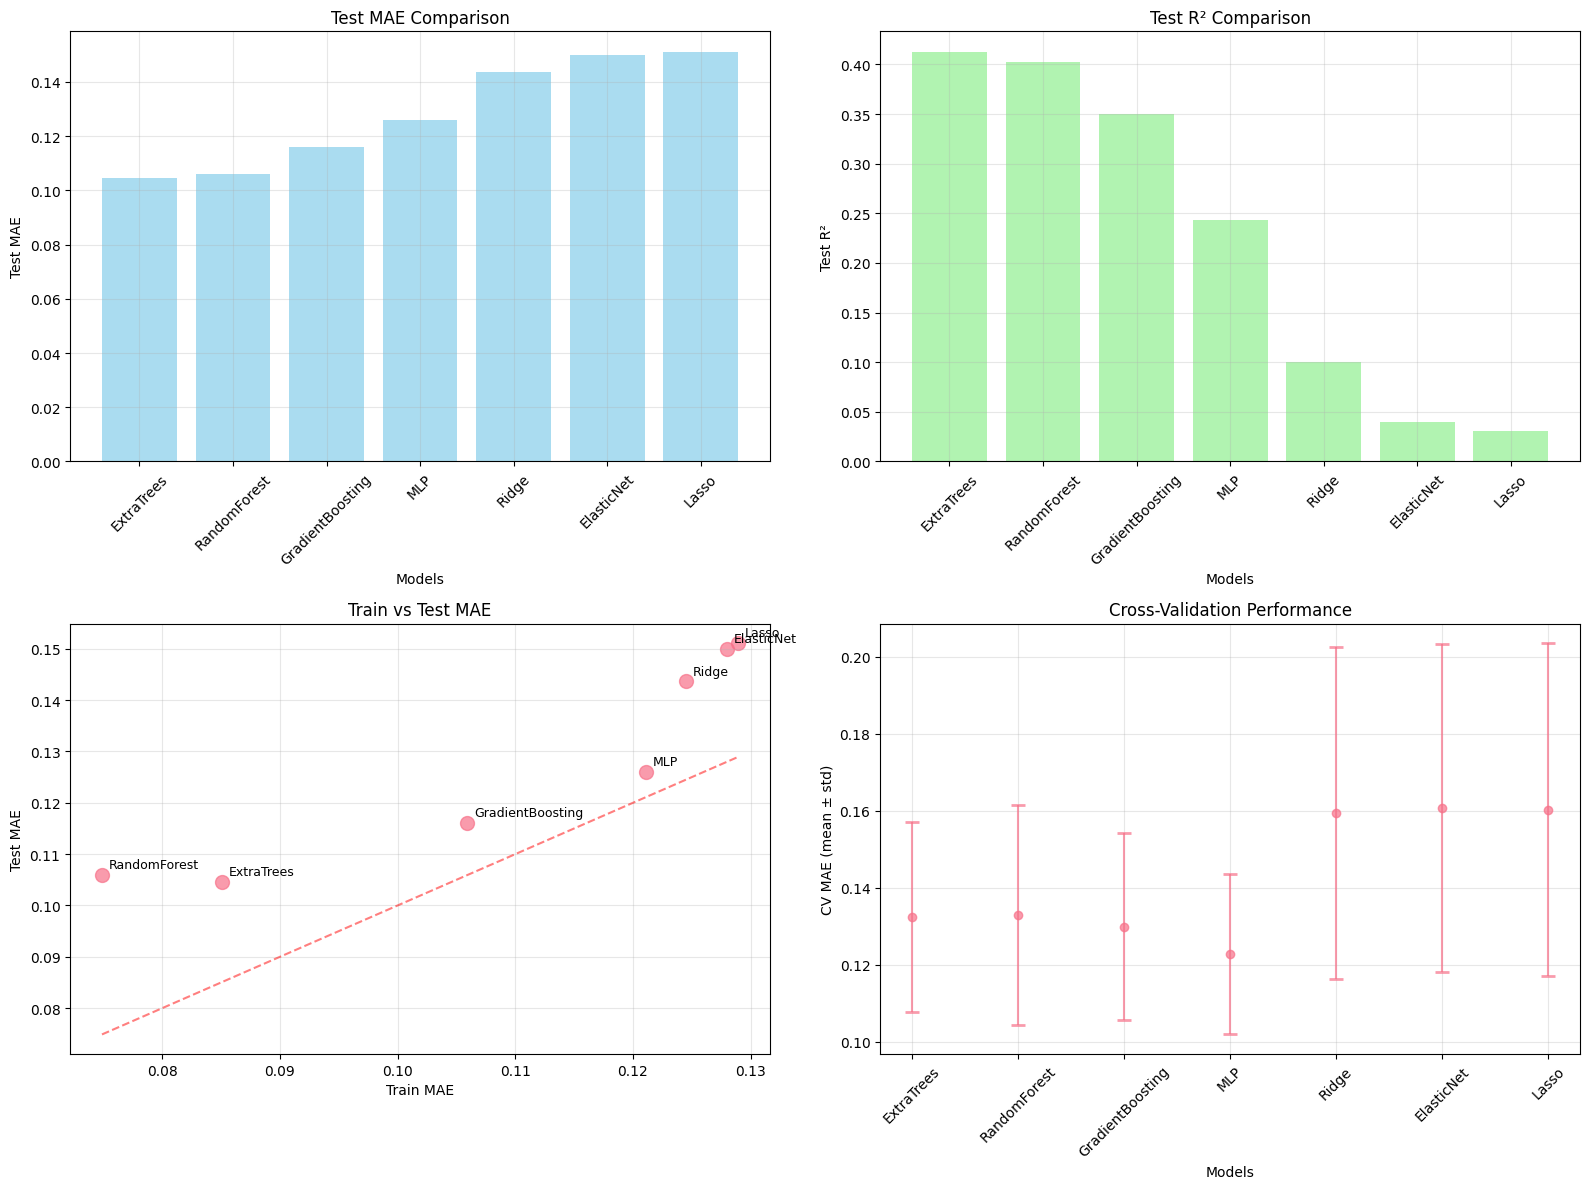

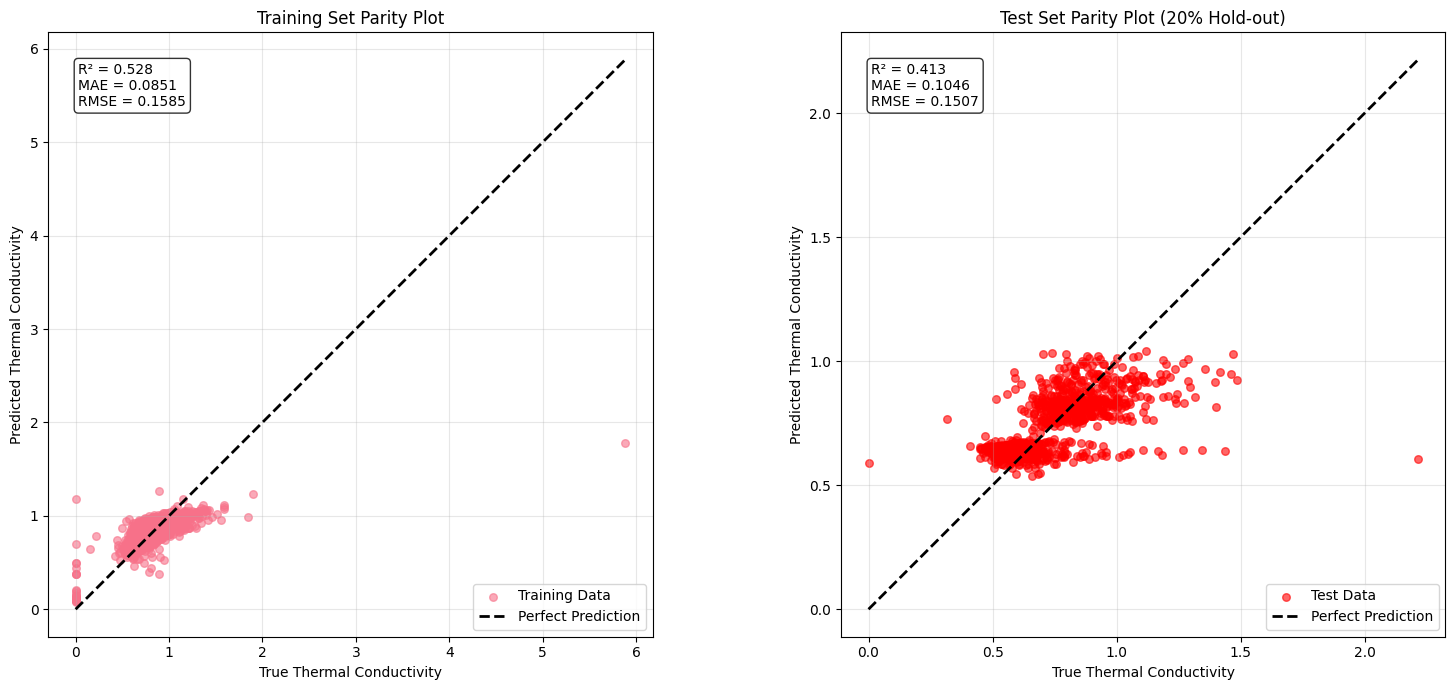

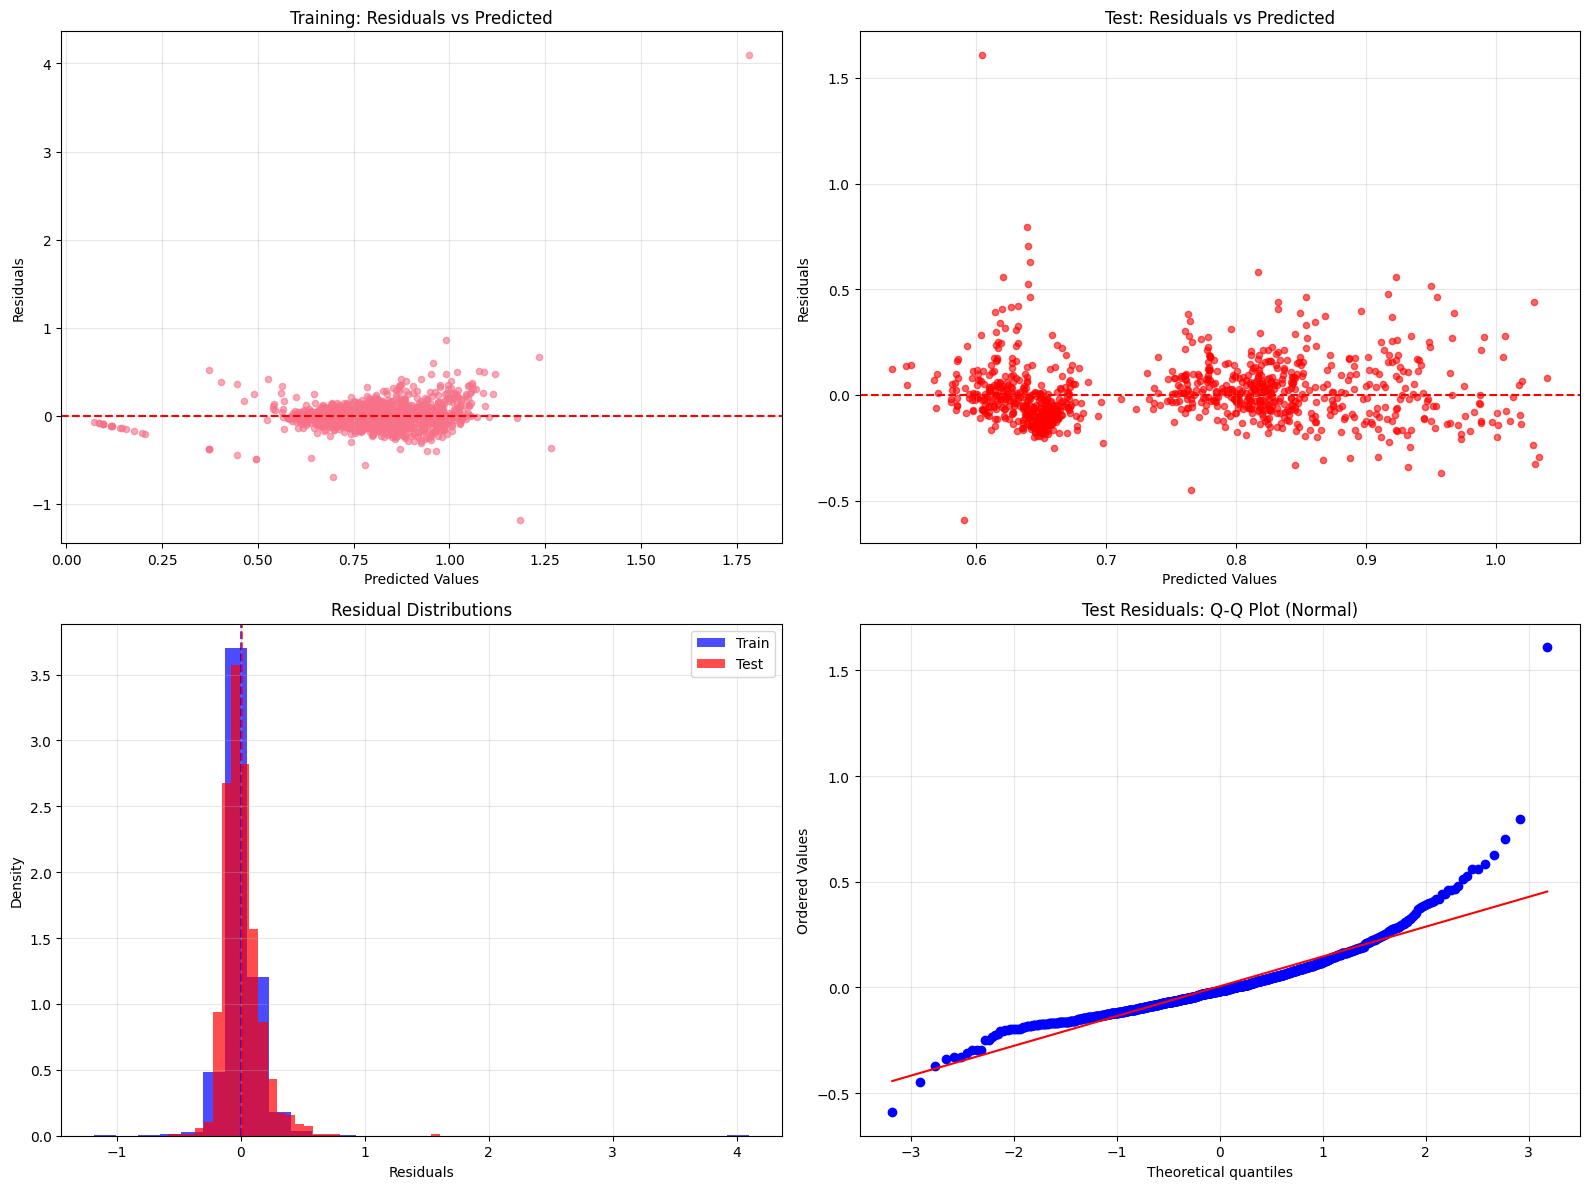

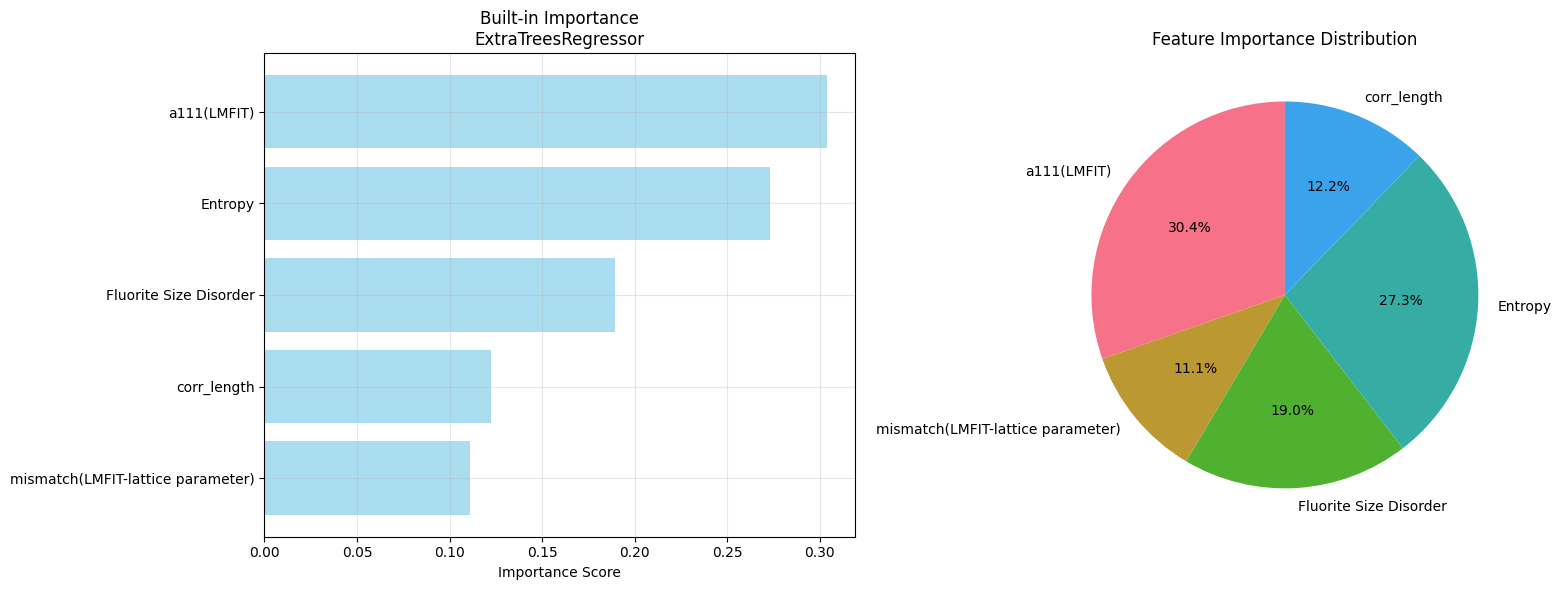


📊 FEATURE IMPORTANCE RANKING:
 1. a111(LMFIT)                        : 0.3037
 2. Entropy                            : 0.2733
 3. Fluorite Size Disorder             : 0.1895
 4. corr_length                        : 0.1223
 5. mismatch(LMFIT-lattice parameter)  : 0.1112


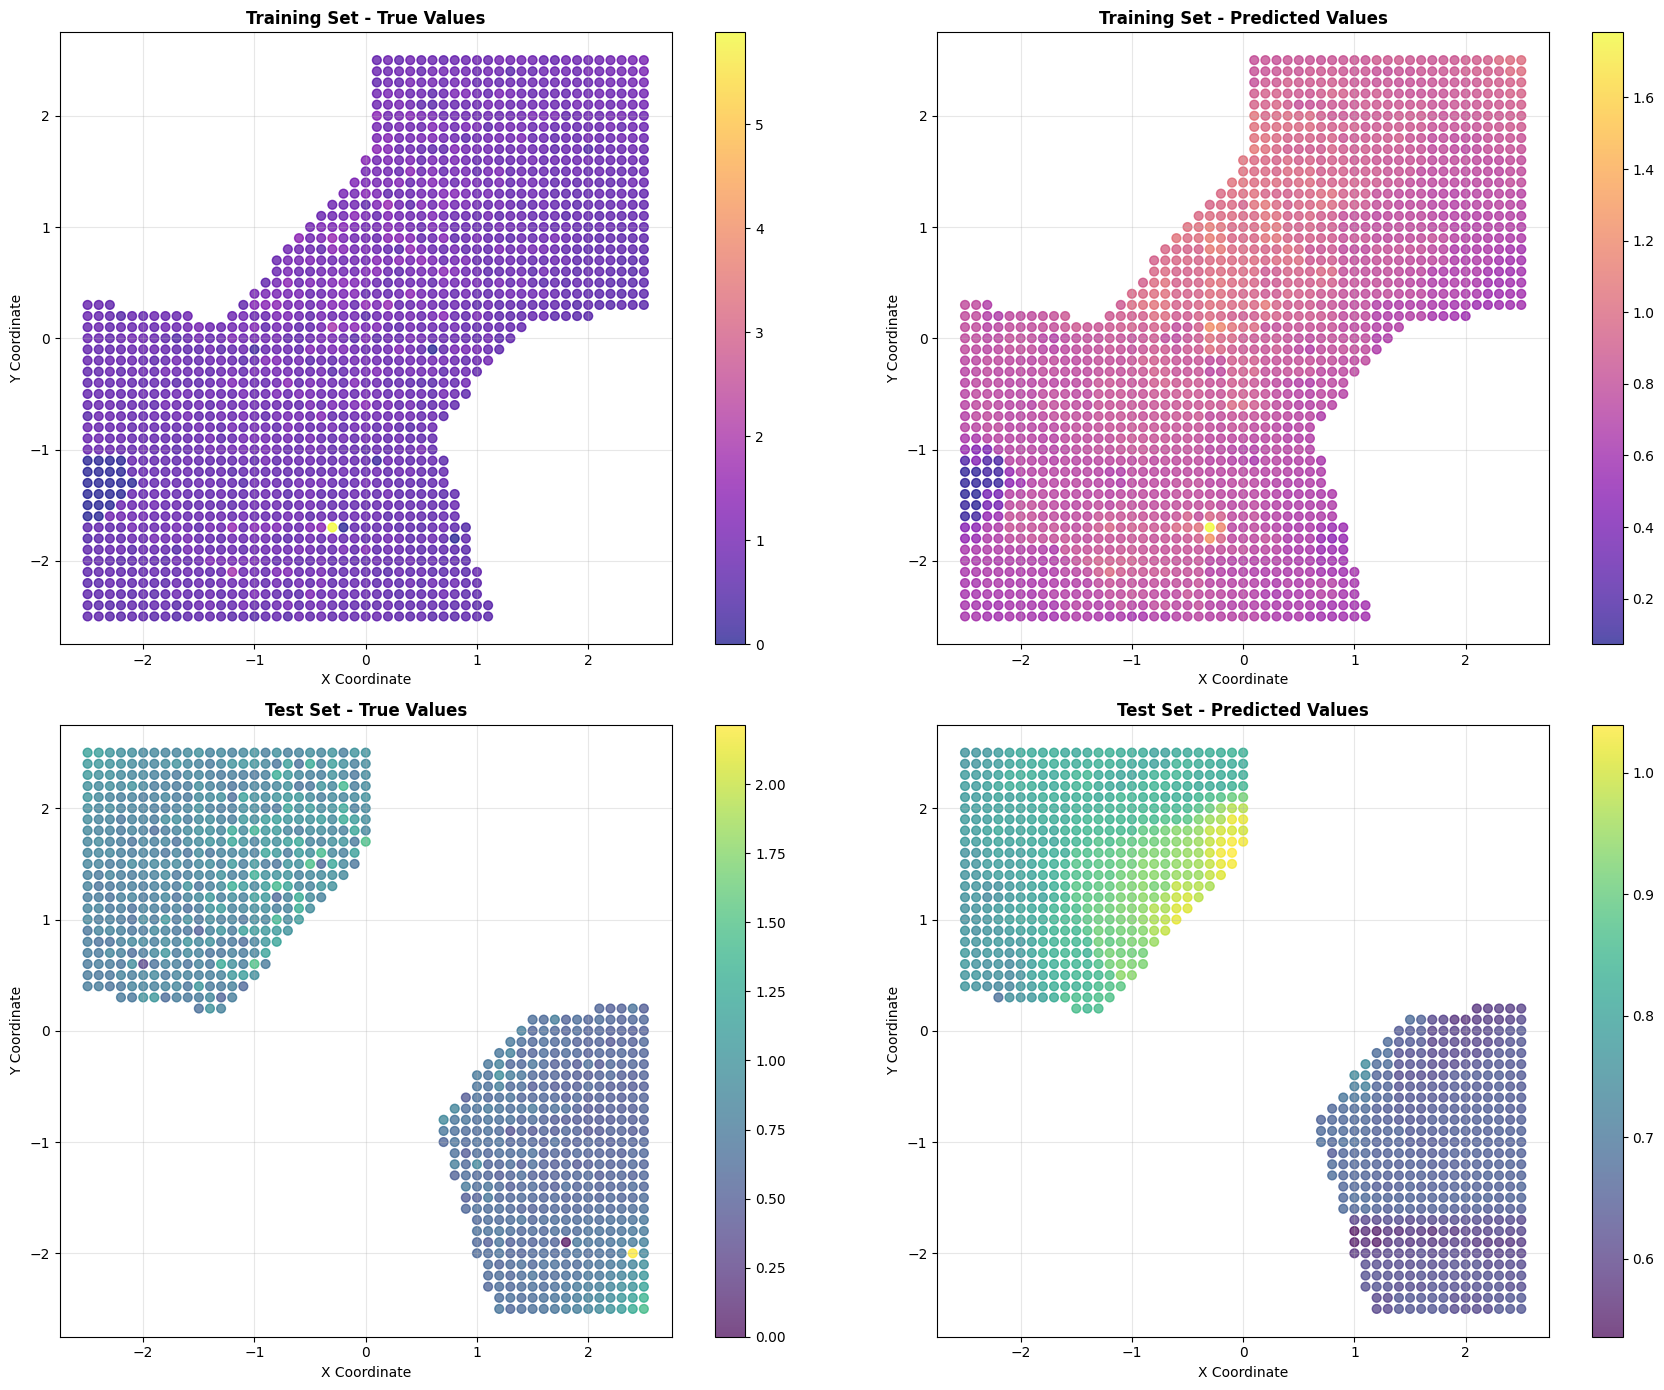

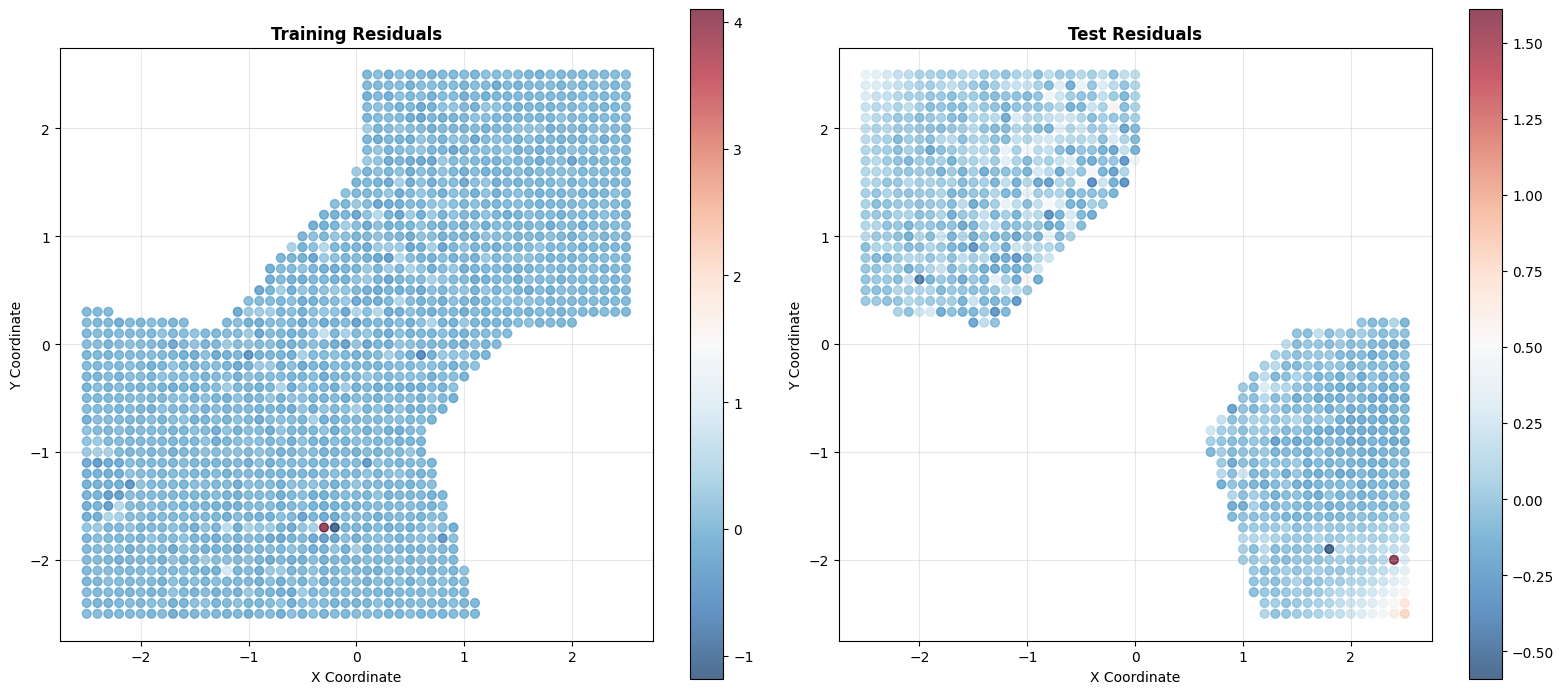

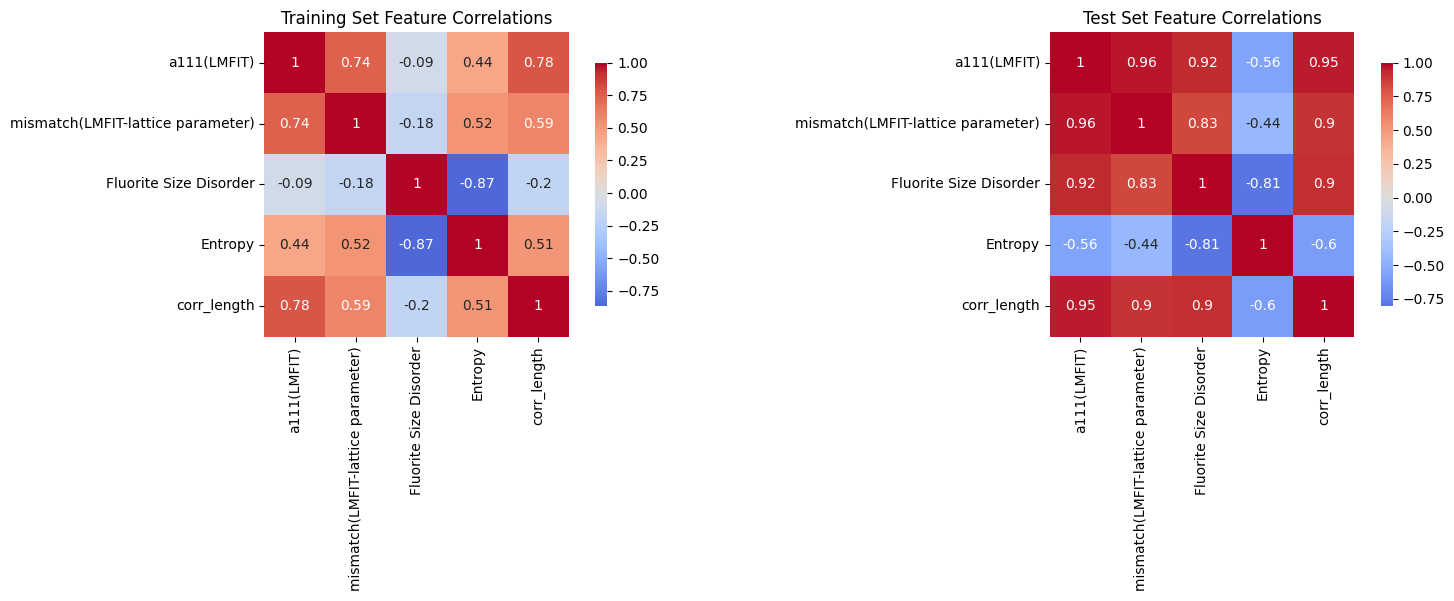


🔗 HIGH FEATURE CORRELATIONS (|r| > 0.5):
   a111(LMFIT) ↔ mismatch(LMFIT-lattice parameter): 0.743
   a111(LMFIT) ↔ corr_length: 0.782
   mismatch(LMFIT-lattice parameter) ↔ Entropy: 0.525
   mismatch(LMFIT-lattice parameter) ↔ corr_length: 0.594
   Fluorite Size Disorder ↔ Entropy: -0.867
   Entropy ↔ corr_length: 0.514

🔬 FEATURE-SPECIFIC THERMAL CONDUCTIVITY PREDICTION REPORT

📋 DATASET SUMMARY:
   • Total samples: 2601
   • Training samples: 1655 (63.6%)
   • Test samples: 946 (36.4%)
   • Target: Thermal Conductivity
   • Coordinates: x, y

🎯 SELECTED FEATURES (5):
    1. a111(LMFIT)                         (mean: 5.2599, std: 0.0114)
    2. mismatch(LMFIT-lattice parameter)   (mean: -0.0052, std: 0.0017)
    3. Fluorite Size Disorder              (mean: 0.1018, std: 0.0018)
    4. Entropy                             (mean: 4.1367, std: 0.0839)
    5. corr_length                         (mean: 8.3659, std: 3.4900)

🏆 BEST MODEL: ExtraTrees
   • Training Performance:
     - MAE:  

/tmp/ipython-input-893864365.py:711: RuntimeWarning: divide by zero encountered in divide
  'relative_error_pct': ((y_train - y_pred_train) / y_train) * 100,
/tmp/ipython-input-893864365.py:723: RuntimeWarning: divide by zero encountered in divide
  'relative_error_pct': ((y_test - y_pred_test) / y_test) * 100,


In [ ]:
# CAMM wafer ML: Feature-Specific Thermal Conductivity Prediction
# ================================================================
# Focused on specific features with comprehensive test evaluation
# Features: a111(LMFIT), mismatch(LMFIT-lattice parameter),
#          Fluorite Size Disorder, Entropy, corr_length

import os
import re
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import GroupShuffleSplit, cross_val_score, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

# Configure logging and warnings
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)
warnings.filterwarnings('ignore', category=UserWarning)

# Configuration
@dataclass
class Config:
    """Configuration for the ML pipeline"""
    data_path: str = "/content/ReZrO_data.csv"
    output_dir: str = "/content/outputs"

    # Specific features to use
    selected_features: List[str] = None

    # Model settings
    n_clusters: int = 6
    test_size: float = 0.20
    cv_folds: int = 5
    random_state: int = 42

    # Model selection
    use_hyperparameter_tuning: bool = True
    n_iter_search: int = 30

    # Visualization
    figure_size: Tuple[int, int] = (12, 8)
    save_plots: bool = True

    def __post_init__(self):
        if self.selected_features is None:
            self.selected_features = [
                'a111(LMFIT)',
                'mismatch(LMFIT-lattice parameter)',
                'Fluorite Size Disorder',
                'Entropy',
                'corr_length'
            ]

class FeatureSpecificPredictor:
    """Thermal conductivity predictor using specific features only"""

    def __init__(self, config: Config):
        self.config = config
        self.df = None
        self.target_col = None
        self.x_col = None
        self.y_col = None
        self.best_model = None
        self.available_features = []

        # Create output directory
        Path(config.output_dir).mkdir(parents=True, exist_ok=True)

    def load_and_validate_data(self) -> pd.DataFrame:
        """Load and validate the dataset"""
        logger.info(f"Loading data from {self.config.data_path}")

        try:
            df = pd.read_csv(self.config.data_path)
            logger.info(f"Data shape: {df.shape}")
            logger.info(f"Available columns: {list(df.columns)}")

            if df.empty:
                raise ValueError("Dataset is empty")

            return df

        except Exception as e:
            logger.error(f"Error loading data: {str(e)}")
            raise

    def detect_columns(self, df: pd.DataFrame) -> Tuple[str, str, str, List[str]]:
        """Detect coordinate, target, and feature columns"""

        def normalize_name(s: str) -> str:
            return re.sub(r'[^a-z0-9()]', '', str(s).lower())

        def find_column(candidates: List[str], columns: List[str]) -> Optional[str]:
            # Create normalized mapping
            norm_map = {col: normalize_name(col) for col in columns}

            for candidate in candidates:
                candidate_norm = normalize_name(candidate)

                # Exact match
                for orig, norm in norm_map.items():
                    if norm == candidate_norm:
                        return orig

                # Partial match
                for orig, norm in norm_map.items():
                    if candidate_norm in norm or norm in candidate_norm:
                        return orig
            return None

        # Find coordinate columns
        x_candidates = ["x", "X", "x_coord", "wafer_x"]
        y_candidates = ["y", "Y", "y_coord", "wafer_y"]

        x_col = find_column(x_candidates, df.columns)
        y_col = find_column(y_candidates, df.columns)

        # Find target column
        target_candidates = [
            "Thermal Conductivity", "ThermalConductivity", "thermal_conductivity",
            "k", "thermal_k", "conductivity", "TC"
        ]
        target_col = find_column(target_candidates, df.columns)

        # Find available features from our selected list
        available_features = []
        missing_features = []

        for feature in self.config.selected_features:
            found_feature = find_column([feature], df.columns)
            if found_feature:
                available_features.append(found_feature)
                logger.info(f"✓ Found feature: '{feature}' -> '{found_feature}'")
            else:
                missing_features.append(feature)
                logger.warning(f"✗ Missing feature: '{feature}'")

        # Validation
        if not x_col or not y_col:
            raise KeyError("Could not find coordinate columns (x, y)")
        if not target_col:
            raise KeyError("Could not find target column (Thermal Conductivity)")
        if not available_features:
            raise KeyError(f"None of the specified features found in dataset")

        if missing_features:
            logger.warning(f"Missing {len(missing_features)} features: {missing_features}")

        logger.info(f"Using {len(available_features)} features: {available_features}")

        return x_col, y_col, target_col, available_features

    def preprocess_data(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray]:
        """Preprocess data with selected features only"""

        # Convert to numeric
        df_processed = df.copy()
        for col in [self.x_col, self.y_col, self.target_col] + self.available_features:
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

        # Remove rows with missing target
        initial_size = len(df_processed)
        df_processed = df_processed.dropna(subset=[self.target_col]).copy()

        # Check for missing feature values
        feature_missing = df_processed[self.available_features].isnull().sum()
        if feature_missing.any():
            logger.info(f"Missing values in features:\n{feature_missing[feature_missing > 0]}")

        logger.info(f"Data after target filtering: {len(df_processed)} samples")

        if df_processed.empty:
            raise ValueError("No valid data remaining after preprocessing")

        # Extract data
        X = df_processed[self.available_features].copy()
        y = df_processed[self.target_col].values
        coords = df_processed[[self.x_col, self.y_col]].values

        # Data summary
        logger.info(f"Feature summary:")
        for feature in self.available_features:
            values = X[feature].dropna()
            logger.info(f"  {feature}: mean={values.mean():.4f}, std={values.std():.4f}, missing={X[feature].isnull().sum()}")

        logger.info(f"Target summary: mean={y.mean():.4f}, std={y.std():.4f}")

        return X, y, coords

    def create_spatial_split(self, coords: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Create spatially-aware train/test split"""

        # Spatial clustering
        kmeans = KMeans(
            n_clusters=self.config.n_clusters,
            random_state=self.config.random_state,
            n_init=10
        )
        spatial_groups = kmeans.fit_predict(coords)

        # Group-based split
        gss = GroupShuffleSplit(
            n_splits=1,
            test_size=self.config.test_size,
            random_state=self.config.random_state
        )

        dummy_X = np.zeros((len(coords), 1))
        train_idx, test_idx = next(gss.split(dummy_X, y, groups=spatial_groups))

        logger.info(f"Spatial split: {len(train_idx)} train, {len(test_idx)} test")
        logger.info(f"Train spatial groups: {set(spatial_groups[train_idx])}")
        logger.info(f"Test spatial groups: {set(spatial_groups[test_idx])}")

        return train_idx, test_idx

    def create_models(self) -> Dict:
        """Create model pipelines"""

        # Preprocessing pipeline
        preprocessing = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        # Model configurations
        models = {
            "Ridge": {
                "model": RidgeCV(alphas=np.logspace(-3, 3, 30), cv=self.config.cv_folds),
                "params": {}
            },
            "Lasso": {
                "model": LassoCV(alphas=np.logspace(-3, 3, 30), cv=self.config.cv_folds),
                "params": {}
            },
            "ElasticNet": {
                "model": ElasticNetCV(alphas=np.logspace(-3, 3, 20), cv=self.config.cv_folds),
                "params": {}
            },
            "RandomForest": {
                "model": RandomForestRegressor(random_state=self.config.random_state, n_jobs=-1),
                "params": {
                    "model__n_estimators": [100, 200, 300, 400],
                    "model__max_depth": [None, 10, 20],
                    "model__min_samples_split": [2, 5, 10],
                    "model__min_samples_leaf": [1, 2, 4]
                }
            },
            "ExtraTrees": {
                "model": ExtraTreesRegressor(random_state=self.config.random_state, n_jobs=-1),
                "params": {
                    "model__n_estimators": [100, 200, 300],
                    "model__max_depth": [None, 10, 20],
                    "model__min_samples_split": [2, 5, 10]
                }
            },
            "GradientBoosting": {
                "model": GradientBoostingRegressor(random_state=self.config.random_state),
                "params": {
                    "model__n_estimators": [100, 200, 300],
                    "model__max_depth": [3, 5, 7],
                    "model__learning_rate": [0.01, 0.1, 0.2],
                    "model__subsample": [0.8, 0.9, 1.0]
                }
            },
            "MLP": {
                "model": MLPRegressor(random_state=self.config.random_state, max_iter=1000),
                "params": {
                    "model__hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50)],
                    "model__alpha": [1e-4, 1e-3, 1e-2],
                    "model__learning_rate_init": [1e-3, 1e-2, 1e-1]
                }
            }
        }

        # Build pipelines
        pipelines = {}
        for name, config in models.items():
            pipeline = Pipeline([
                ("preprocessing", preprocessing),
                ("model", config["model"])
            ])
            pipelines[name] = {"pipeline": pipeline, "params": config["params"]}

        return pipelines

    def train_and_evaluate_models(self, X_train, y_train, X_test, y_test):
        """Train all models and evaluate performance"""

        pipelines = self.create_models()
        results = []
        fitted_models = {}

        logger.info("Training models with selected features...")

        for name, config in pipelines.items():
            logger.info(f"Training {name}...")

            try:
                pipeline = config["pipeline"]
                param_grid = config["params"]

                if self.config.use_hyperparameter_tuning and param_grid:
                    # Hyperparameter tuning
                    search = RandomizedSearchCV(
                        pipeline, param_grid,
                        cv=self.config.cv_folds,
                        scoring='neg_mean_absolute_error',
                        n_jobs=-1,
                        n_iter=self.config.n_iter_search,
                        random_state=self.config.random_state,
                        verbose=0
                    )
                    search.fit(X_train, y_train)
                    best_pipeline = search.best_estimator_
                    best_params = search.best_params_
                else:
                    # No hyperparameter tuning
                    pipeline.fit(X_train, y_train)
                    best_pipeline = pipeline
                    best_params = {}

                # Predictions
                y_pred_train = best_pipeline.predict(X_train)
                y_pred_test = best_pipeline.predict(X_test)

                # Cross-validation on training set
                cv_scores = cross_val_score(
                    best_pipeline, X_train, y_train,
                    cv=self.config.cv_folds,
                    scoring='neg_mean_absolute_error'
                )

                # Calculate metrics
                train_metrics = self.calculate_metrics(y_train, y_pred_train, "Train")
                test_metrics = self.calculate_metrics(y_test, y_pred_test, "Test")

                result = {
                    "Model": name,
                    "CV_MAE_mean": -cv_scores.mean(),
                    "CV_MAE_std": cv_scores.std(),
                    **{f"Train_{k}": v for k, v in train_metrics.items()},
                    **{f"Test_{k}": v for k, v in test_metrics.items()},
                    "Best_Params": str(best_params) if best_params else "None"
                }

                results.append(result)
                fitted_models[name] = best_pipeline

                logger.info(f"{name}: Test MAE={test_metrics['MAE']:.4f}, Test R²={test_metrics['R2']:.4f}")

            except Exception as e:
                logger.error(f"Error training {name}: {str(e)}")
                continue

        if not results:
            raise RuntimeError("No models were successfully trained")

        # Select best model based on test MAE
        results_df = pd.DataFrame(results).sort_values("Test_MAE")
        best_model_name = results_df.iloc[0]["Model"]
        self.best_model = fitted_models[best_model_name]

        logger.info(f"Best model: {best_model_name}")

        return results_df, fitted_models

    def calculate_metrics(self, y_true, y_pred, prefix=""):
        """Calculate comprehensive metrics"""
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)

        # Additional metrics
        mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100

        return {
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2,
            "MAPE": mape
        }

    def create_comprehensive_plots(self, X_train, y_train, X_test, y_test, coords_train, coords_test, results_df):
        """Create comprehensive visualization suite"""

        # Predictions
        y_pred_train = self.best_model.predict(X_train)
        y_pred_test = self.best_model.predict(X_test)

        # Set up plotting style
        plt.style.use('default')
        sns.set_palette("husl")

        # 1. Model performance comparison
        self.plot_model_comparison(results_df)

        # 2. Train vs Test parity plots
        self.plot_train_test_parity(y_train, y_pred_train, y_test, y_pred_test)

        # 3. Residual analysis
        self.plot_residual_analysis(y_train, y_pred_train, y_test, y_pred_test)

        # 4. Feature importance
        self.plot_feature_importance(X_test, y_test)

        # 5. Wafer maps comparison
        self.plot_wafer_comparison(coords_train, coords_test, y_train, y_test, y_pred_train, y_pred_test)

        # 6. Feature correlation heatmap
        self.plot_feature_correlation(X_train, X_test)

    def plot_model_comparison(self, results_df):
        """Plot model performance comparison"""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

        models = results_df['Model']
        n_models = len(models)
        x_pos = np.arange(n_models)

        # Test MAE comparison
        ax1.bar(x_pos, results_df['Test_MAE'], alpha=0.7, color='skyblue')
        ax1.set_xlabel('Models')
        ax1.set_ylabel('Test MAE')
        ax1.set_title('Test MAE Comparison')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(models, rotation=45)
        ax1.grid(True, alpha=0.3)

        # Test R² comparison
        ax2.bar(x_pos, results_df['Test_R2'], alpha=0.7, color='lightgreen')
        ax2.set_xlabel('Models')
        ax2.set_ylabel('Test R²')
        ax2.set_title('Test R² Comparison')
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels(models, rotation=45)
        ax2.grid(True, alpha=0.3)

        # Train vs Test MAE
        ax3.scatter(results_df['Train_MAE'], results_df['Test_MAE'], s=100, alpha=0.7)
        for i, model in enumerate(models):
            ax3.annotate(model, (results_df.iloc[i]['Train_MAE'], results_df.iloc[i]['Test_MAE']),
                        xytext=(5, 5), textcoords='offset points', fontsize=9)
        ax3.plot([results_df['Train_MAE'].min(), results_df['Train_MAE'].max()],
                [results_df['Train_MAE'].min(), results_df['Train_MAE'].max()], 'r--', alpha=0.5)
        ax3.set_xlabel('Train MAE')
        ax3.set_ylabel('Test MAE')
        ax3.set_title('Train vs Test MAE')
        ax3.grid(True, alpha=0.3)

        # Cross-validation scores
        ax4.errorbar(x_pos, results_df['CV_MAE_mean'], yerr=results_df['CV_MAE_std'],
                    fmt='o', capsize=5, capthick=2, alpha=0.7)
        ax4.set_xlabel('Models')
        ax4.set_ylabel('CV MAE (mean ± std)')
        ax4.set_title('Cross-Validation Performance')
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels(models, rotation=45)
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        if self.config.save_plots:
            plt.savefig(f"{self.config.output_dir}/model_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_train_test_parity(self, y_train, y_pred_train, y_test, y_pred_test):
        """Plot train vs test parity comparison"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        # Training parity
        train_metrics = self.calculate_metrics(y_train, y_pred_train)
        ax1.scatter(y_train, y_pred_train, alpha=0.6, s=30, label='Training Data')

        min_val, max_val = min(np.min(y_train), np.min(y_pred_train)), max(np.max(y_train), np.max(y_pred_train))
        ax1.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')

        stats_text = f"R² = {train_metrics['R2']:.3f}\nMAE = {train_metrics['MAE']:.4f}\nRMSE = {train_metrics['RMSE']:.4f}"
        ax1.text(0.05, 0.95, stats_text, transform=ax1.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        ax1.set_xlabel('True Thermal Conductivity')
        ax1.set_ylabel('Predicted Thermal Conductivity')
        ax1.set_title('Training Set Parity Plot')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_aspect('equal', adjustable='box')

        # Test parity
        test_metrics = self.calculate_metrics(y_test, y_pred_test)
        ax2.scatter(y_test, y_pred_test, alpha=0.6, s=30, color='red', label='Test Data')

        min_val, max_val = min(np.min(y_test), np.min(y_pred_test)), max(np.max(y_test), np.max(y_pred_test))
        ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')

        stats_text = f"R² = {test_metrics['R2']:.3f}\nMAE = {test_metrics['MAE']:.4f}\nRMSE = {test_metrics['RMSE']:.4f}"
        ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        ax2.set_xlabel('True Thermal Conductivity')
        ax2.set_ylabel('Predicted Thermal Conductivity')
        ax2.set_title('Test Set Parity Plot (20% Hold-out)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_aspect('equal', adjustable='box')

        plt.tight_layout()
        if self.config.save_plots:
            plt.savefig(f"{self.config.output_dir}/parity_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_residual_analysis(self, y_train, y_pred_train, y_test, y_pred_test):
        """Plot residual analysis for train and test sets"""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

        train_residuals = y_train - y_pred_train
        test_residuals = y_test - y_pred_test

        # Train residuals vs predicted
        ax1.scatter(y_pred_train, train_residuals, alpha=0.6, s=20)
        ax1.axhline(y=0, color='red', linestyle='--')
        ax1.set_xlabel('Predicted Values')
        ax1.set_ylabel('Residuals')
        ax1.set_title('Training: Residuals vs Predicted')
        ax1.grid(True, alpha=0.3)

        # Test residuals vs predicted
        ax2.scatter(y_pred_test, test_residuals, alpha=0.6, s=20, color='red')
        ax2.axhline(y=0, color='red', linestyle='--')
        ax2.set_xlabel('Predicted Values')
        ax2.set_ylabel('Residuals')
        ax2.set_title('Test: Residuals vs Predicted')
        ax2.grid(True, alpha=0.3)

        # Residual histograms
        ax3.hist(train_residuals, bins=30, alpha=0.7, density=True, label='Train', color='blue')
        ax3.hist(test_residuals, bins=30, alpha=0.7, density=True, label='Test', color='red')
        ax3.axvline(np.mean(train_residuals), color='blue', linestyle='--', alpha=0.7)
        ax3.axvline(np.mean(test_residuals), color='red', linestyle='--', alpha=0.7)
        ax3.set_xlabel('Residuals')
        ax3.set_ylabel('Density')
        ax3.set_title('Residual Distributions')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # Q-Q plot for test residuals
        stats.probplot(test_residuals, dist="norm", plot=ax4)
        ax4.set_title('Test Residuals: Q-Q Plot (Normal)')
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        if self.config.save_plots:
            plt.savefig(f"{self.config.output_dir}/residual_analysis.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_feature_importance(self, X_test, y_test):
        """Plot feature importance analysis"""
        try:
            model = self.best_model.named_steps["model"]

            if hasattr(model, "feature_importances_"):
                importances = model.feature_importances_
                method = "Built-in Importance"
            else:
                logger.info("Computing permutation importance...")
                perm_result = permutation_importance(
                    self.best_model, X_test, y_test,
                    n_repeats=10, random_state=self.config.random_state, n_jobs=-1
                )
                importances = perm_result.importances_mean
                method = "Permutation Importance"

            # Create importance plot
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

            # Horizontal bar plot
            indices = np.argsort(importances)
            ax1.barh(range(len(importances)), importances[indices], color='skyblue', alpha=0.7)
            ax1.set_yticks(range(len(importances)))
            ax1.set_yticklabels([self.available_features[i] for i in indices])
            ax1.set_xlabel('Importance Score')
            ax1.set_title(f'{method}\n{self.best_model.named_steps["model"].__class__.__name__}')
            ax1.grid(True, alpha=0.3)

            # Pie chart
            ax2.pie(importances, labels=self.available_features, autopct='%1.1f%%', startangle=90)
            ax2.set_title('Feature Importance Distribution')

            plt.tight_layout()
            if self.config.save_plots:
                plt.savefig(f"{self.config.output_dir}/feature_importance.png", dpi=300, bbox_inches='tight')
            plt.show()

            # Print importance ranking
            print("\n📊 FEATURE IMPORTANCE RANKING:")
            for i, idx in enumerate(np.argsort(importances)[::-1]):
                print(f"{i+1:2d}. {self.available_features[idx]:<35}: {importances[idx]:.4f}")

        except Exception as e:
            logger.warning(f"Could not generate feature importance: {e}")

    def plot_wafer_comparison(self, coords_train, coords_test, y_train, y_test, y_pred_train, y_pred_test):
        """Plot wafer maps for train and test sets"""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

        def create_wafer_plot(ax, x, y, values, title, cmap='viridis', alpha=0.7):
            scatter = ax.scatter(x, y, c=values, s=40, cmap=cmap, alpha=alpha)
            ax.set_aspect('equal', adjustable='box')
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('X Coordinate')
            ax.set_ylabel('Y Coordinate')
            ax.grid(True, alpha=0.3)
            plt.colorbar(scatter, ax=ax)

        # Training data - true vs predicted
        create_wafer_plot(ax1, coords_train[:, 0], coords_train[:, 1], y_train,
                         'Training Set - True Values', 'plasma')
        create_wafer_plot(ax2, coords_train[:, 0], coords_train[:, 1], y_pred_train,
                         'Training Set - Predicted Values', 'plasma')

        # Test data - true vs predicted
        create_wafer_plot(ax3, coords_test[:, 0], coords_test[:, 1], y_test,
                         'Test Set - True Values', 'viridis')
        create_wafer_plot(ax4, coords_test[:, 0], coords_test[:, 1], y_pred_test,
                         'Test Set - Predicted Values', 'viridis')

        plt.tight_layout()
        if self.config.save_plots:
            plt.savefig(f"{self.config.output_dir}/wafer_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()

        # Additional residual wafer maps
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        train_residuals = y_train - y_pred_train
        test_residuals = y_test - y_pred_test

        create_wafer_plot(ax1, coords_train[:, 0], coords_train[:, 1], train_residuals,
                         'Training Residuals', 'RdBu_r')
        create_wafer_plot(ax2, coords_test[:, 0], coords_test[:, 1], test_residuals,
                         'Test Residuals', 'RdBu_r')

        plt.tight_layout()
        if self.config.save_plots:
            plt.savefig(f"{self.config.output_dir}/residual_wafers.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_feature_correlation(self, X_train, X_test):
        """Plot feature correlation analysis"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Training set correlations
        train_corr = X_train[self.available_features].corr()
        sns.heatmap(train_corr, annot=True, cmap='coolwarm', center=0,
                   square=True, ax=ax1, cbar_kws={"shrink": .8})
        ax1.set_title('Training Set Feature Correlations')

        # Test set correlations
        test_corr = X_test[self.available_features].corr()
        sns.heatmap(test_corr, annot=True, cmap='coolwarm', center=0,
                   square=True, ax=ax2, cbar_kws={"shrink": .8})
        ax2.set_title('Test Set Feature Correlations')

        plt.tight_layout()
        if self.config.save_plots:
            plt.savefig(f"{self.config.output_dir}/feature_correlations.png", dpi=300, bbox_inches='tight')
        plt.show()

        # Print high correlations
        print("\n🔗 HIGH FEATURE CORRELATIONS (|r| > 0.5):")
        for i in range(len(self.available_features)):
            for j in range(i+1, len(self.available_features)):
                corr_val = train_corr.iloc[i, j]
                if abs(corr_val) > 0.5:
                    print(f"   {self.available_features[i]} ↔ {self.available_features[j]}: {corr_val:.3f}")

    def save_results(self, X_train, y_train, X_test, y_test, coords_train, coords_test, results_df):
        """Save comprehensive results"""

        # Predictions
        y_pred_train = self.best_model.predict(X_train)
        y_pred_test = self.best_model.predict(X_test)

        # Training predictions DataFrame
        train_df = pd.DataFrame({
            'x_coord': coords_train[:, 0],
            'y_coord': coords_train[:, 1],
            'true_thermal_conductivity': y_train,
            'predicted_thermal_conductivity': y_pred_train,
            'residual': y_train - y_pred_train,
            'abs_residual': np.abs(y_train - y_pred_train),
            'relative_error_pct': ((y_train - y_pred_train) / y_train) * 100,
            'dataset': 'train'
        })

        # Test predictions DataFrame
        test_df = pd.DataFrame({
            'x_coord': coords_test[:, 0],
            'y_coord': coords_test[:, 1],
            'true_thermal_conductivity': y_test,
            'predicted_thermal_conductivity': y_pred_test,
            'residual': y_test - y_pred_test,
            'abs_residual': np.abs(y_test - y_pred_test),
            'relative_error_pct': ((y_test - y_pred_test) / y_test) * 100,
            'dataset': 'test'
        })

        # Add feature values to predictions
        for feature in self.available_features:
            train_df[feature] = X_train[feature].values
            test_df[feature] = X_test[feature].values

        # Combined predictions
        all_predictions = pd.concat([train_df, test_df], ignore_index=True)

        # Save files
        pred_path = f"{self.config.output_dir}/thermal_predictions_with_features.csv"
        all_predictions.to_csv(pred_path, index=False)

        results_path = f"{self.config.output_dir}/model_comparison_results.csv"
        results_df.to_csv(results_path, index=False)

        logger.info(f"Results saved: {pred_path}")
        logger.info(f"Model comparison saved: {results_path}")

        # Save model
        try:
            import joblib
            model_path = f"{self.config.output_dir}/best_model.joblib"
            joblib.dump(self.best_model, model_path)
            logger.info(f"Best model saved: {model_path}")
        except ImportError:
            logger.warning("joblib not available - model not saved")

        return all_predictions, results_df

    def generate_comprehensive_report(self, results_df, all_predictions):
        """Generate detailed final report"""

        best_result = results_df.iloc[0]
        train_data = all_predictions[all_predictions['dataset'] == 'train']
        test_data = all_predictions[all_predictions['dataset'] == 'test']

        print("\n" + "="*90)
        print("🔬 FEATURE-SPECIFIC THERMAL CONDUCTIVITY PREDICTION REPORT")
        print("="*90)

        print(f"\n📋 DATASET SUMMARY:")
        print(f"   • Total samples: {len(all_predictions)}")
        print(f"   • Training samples: {len(train_data)} ({len(train_data)/len(all_predictions)*100:.1f}%)")
        print(f"   • Test samples: {len(test_data)} ({len(test_data)/len(all_predictions)*100:.1f}%)")
        print(f"   • Target: {self.target_col}")
        print(f"   • Coordinates: {self.x_col}, {self.y_col}")

        print(f"\n🎯 SELECTED FEATURES ({len(self.available_features)}):")
        for i, feature in enumerate(self.available_features, 1):
            feature_data = all_predictions[feature].dropna()
            print(f"   {i:2d}. {feature:<35} (mean: {feature_data.mean():.4f}, std: {feature_data.std():.4f})")

        print(f"\n🏆 BEST MODEL: {best_result['Model']}")
        print(f"   • Training Performance:")
        print(f"     - MAE:  {best_result['Train_MAE']:.6f}")
        print(f"     - RMSE: {best_result['Train_RMSE']:.6f}")
        print(f"     - R²:   {best_result['Train_R2']:.6f}")
        print(f"   • Test Performance (20% Hold-out):")
        print(f"     - MAE:  {best_result['Test_MAE']:.6f}")
        print(f"     - RMSE: {best_result['Test_RMSE']:.6f}")
        print(f"     - R²:   {best_result['Test_R2']:.6f}")
        print(f"   • Cross-Validation: {best_result['CV_MAE_mean']:.6f} ± {best_result['CV_MAE_std']:.6f}")

        print(f"\n📊 ALL MODEL COMPARISON:")
        for _, row in results_df.iterrows():
            print(f"   • {row['Model']:<15}: Test R²={row['Test_R2']:.4f}, Test MAE={row['Test_MAE']:.6f}")

        print(f"\n📈 TEST SET ANALYSIS (20% Hold-out):")
        print(f"   • Mean absolute error: {test_data['abs_residual'].mean():.6f}")
        print(f"   • Max absolute error:  {test_data['abs_residual'].max():.6f}")
        print(f"   • Mean relative error: {test_data['relative_error_pct'].abs().mean():.2f}%")
        print(f"   • Residual std:        {test_data['residual'].std():.6f}")

        # Prediction ranges
        print(f"\n🎯 PREDICTION RANGES:")
        print(f"   • True values  - Train: [{train_data['true_thermal_conductivity'].min():.4f}, {train_data['true_thermal_conductivity'].max():.4f}]")
        print(f"   • True values  - Test:  [{test_data['true_thermal_conductivity'].min():.4f}, {test_data['true_thermal_conductivity'].max():.4f}]")
        print(f"   • Predictions  - Train: [{train_data['predicted_thermal_conductivity'].min():.4f}, {train_data['predicted_thermal_conductivity'].max():.4f}]")
        print(f"   • Predictions  - Test:  [{test_data['predicted_thermal_conductivity'].min():.4f}, {test_data['predicted_thermal_conductivity'].max():.4f}]")

        print(f"\n📁 SAVED FILES:")
        print(f"   • Predictions with features: thermal_predictions_with_features.csv")
        print(f"   • Model comparison results:  model_comparison_results.csv")
        print(f"   • Best trained model:        best_model.joblib")
        print(f"   • All visualization plots:   *.png")

        # Feature statistics
        print(f"\n🔍 FEATURE STATISTICS:")
        for feature in self.available_features:
            train_vals = train_data[feature].dropna()
            test_vals = test_data[feature].dropna()
            print(f"   {feature}:")
            print(f"     Train: mean={train_vals.mean():.4f}, std={train_vals.std():.4f}, range=[{train_vals.min():.4f}, {train_vals.max():.4f}]")
            print(f"     Test:  mean={test_vals.mean():.4f}, std={test_vals.std():.4f}, range=[{test_vals.min():.4f}, {test_vals.max():.4f}]")

        print("="*90)
        print("✅ Analysis complete! Check the output directory for detailed results and visualizations.")
        print("="*90)

    def run_pipeline(self):
        """Execute the complete pipeline"""
        logger.info("Starting feature-specific thermal conductivity prediction pipeline")

        try:
            # Load and validate data
            self.df = self.load_and_validate_data()

            # Detect columns and features
            self.x_col, self.y_col, self.target_col, self.available_features = self.detect_columns(self.df)

            # Preprocess data
            X, y, coords = self.preprocess_data(self.df)

            # Create spatial split
            train_idx, test_idx = self.create_spatial_split(coords, y)

            # Split data
            X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
            y_train, y_test = y[train_idx], y[test_idx]
            coords_train, coords_test = coords[train_idx], coords[test_idx]

            # Train and evaluate models
            results_df, fitted_models = self.train_and_evaluate_models(X_train, y_train, X_test, y_test)

            # Create visualizations
            self.create_comprehensive_plots(X_train, y_train, X_test, y_test,
                                          coords_train, coords_test, results_df)

            # Save results
            all_predictions, results_df = self.save_results(X_train, y_train, X_test, y_test,
                                                          coords_train, coords_test, results_df)

            # Generate final report
            self.generate_comprehensive_report(results_df, all_predictions)

            return {
                "predictions": all_predictions,
                "results": results_df,
                "best_model": self.best_model,
                "features_used": self.available_features
            }

        except Exception as e:
            logger.error(f"Pipeline failed: {str(e)}")
            raise


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""

    # Define the specific features to use
    selected_features = [
        'a111(LMFIT)',
        'mismatch(LMFIT-lattice parameter)',
        'Fluorite Size Disorder',
        'Entropy',
        'corr_length'
    ]

    # Configuration
    config = Config(
        data_path="/content/ReZrO_data.csv",
        output_dir="/content/outputs",
        selected_features=selected_features,
        n_clusters=6,
        test_size=0.20,  # 20% test set
        cv_folds=5,
        use_hyperparameter_tuning=True,
        n_iter_search=30,
        save_plots=True
    )

    # Initialize and run pipeline
    predictor = FeatureSpecificPredictor(config)

    print("🚀 Starting Feature-Specific Thermal Conductivity Prediction")
    print(f"📋 Selected Features: {selected_features}")
    print(f"📊 Test Set Size: {config.test_size*100:.0f}% (spatially separated)")
    print(f"🎯 Output Directory: {config.output_dir}")
    print("-" * 80)

    try:
        results = predictor.run_pipeline()

        print(f"\n🎉 Pipeline completed successfully!")
        print(f"📈 Best Model: {results['results'].iloc[0]['Model']}")
        print(f"🎯 Test R²: {results['results'].iloc[0]['Test_R2']:.4f}")
        print(f"📊 Features Used: {len(results['features_used'])}")

        return results

    except FileNotFoundError:
        print("❌ Error: Data file not found. Please check the file path in the configuration.")
        return None
    except KeyError as e:
        print(f"❌ Error: Required columns not found: {e}")
        print("Please check that your CSV contains the required features and target column.")
        return None
    except Exception as e:
        print(f"❌ Pipeline failed: {str(e)}")
        logger.exception("Full error details:")
        return None


if __name__ == "__main__":
    # Execute pipeline
    results = main()

    if results:
        print("\n" + "="*50)
        print("📊 RESULTS SUMMARY")
        print("="*50)
        print("✅ Pipeline completed successfully!")
        print("📁 Check the output directory for:")
        print("   • Comprehensive prediction CSV with all features")
        print("   • Model comparison results")
        print("   • Trained model file")
        print("   • Detailed visualization plots")
        print("   • Train vs Test performance comparison")
        print("\n🔍 Key insights:")
        print("   • Spatial train/test split ensures robust evaluation")
        print("   • 20% test set provides unbiased performance estimate")
        print("   • Feature importance analysis shows most predictive variables")
        print("   • Wafer maps reveal spatial prediction patterns")